# Hour 4: Deep Learning Foundations: Perceptron & Activation Functions

In this notebook, we will:
1. Build a `Perceptron` from scratch in NumPy.
2. Train it on logical AND and OR gates.
3. Prove its failure on non-linearly separable XOR gate.
4. Implement and plot major activation functions (Sigmoid, Tanh, ReLU, LeakyReLU, GELU).

In [1]:
import numpy as np
import matplotlib.pyplot as plt

print('Perceptron & Activations setup complete!')

Perceptron & Activations setup complete!


## Step 1: Perceptron Class Implementation from Scratch

In [2]:
class Perceptron:
    def __init__(self, input_dim, lr=0.1, epochs=100):
        self.weights = np.zeros(input_dim)
        self.bias = 0.0
        self.lr = lr
        self.epochs = epochs
        self.errors = []

    def step_function(self, z):
        return np.where(z >= 0.0, 1, 0)

    def predict(self, X):
        z = np.dot(X, self.weights) + self.bias
        return self.step_function(z)

    def fit(self, X, y):
        for epoch in range(self.epochs):
            total_error = 0
            for xi, target in zip(X, y):
                pred = self.predict(xi)
                update = self.lr * (target - pred)
                self.weights += update * xi
                self.bias += update
                total_error += int(update != 0.0)
            self.errors.append(total_error)
            if total_error == 0:
                print(f'Converged at epoch {epoch+1}')
                break
        return self

## Step 2: Training on Logic Gates (AND, OR, XOR)

In [3]:
X_logic = np.array([[0,0], [0,1], [1,0], [1,1]])
y_and = np.array([0, 0, 0, 1])
y_or  = np.array([0, 1, 1, 1])
y_xor = np.array([0, 1, 1, 0])

p_and = Perceptron(input_dim=2).fit(X_logic, y_and)
print('AND Predictions:', p_and.predict(X_logic))

p_or = Perceptron(input_dim=2).fit(X_logic, y_or)
print('OR Predictions:', p_or.predict(X_logic))

p_xor = Perceptron(input_dim=2).fit(X_logic, y_xor)
print('XOR Predictions (Failed):', p_xor.predict(X_logic))

Converged at epoch 4
AND Predictions: [0 0 0 1]
Converged at epoch 4
OR Predictions: [0 1 1 1]
XOR Predictions (Failed): [1 1 0 0]


## Step 3: Activation Functions Implementation & Visualization

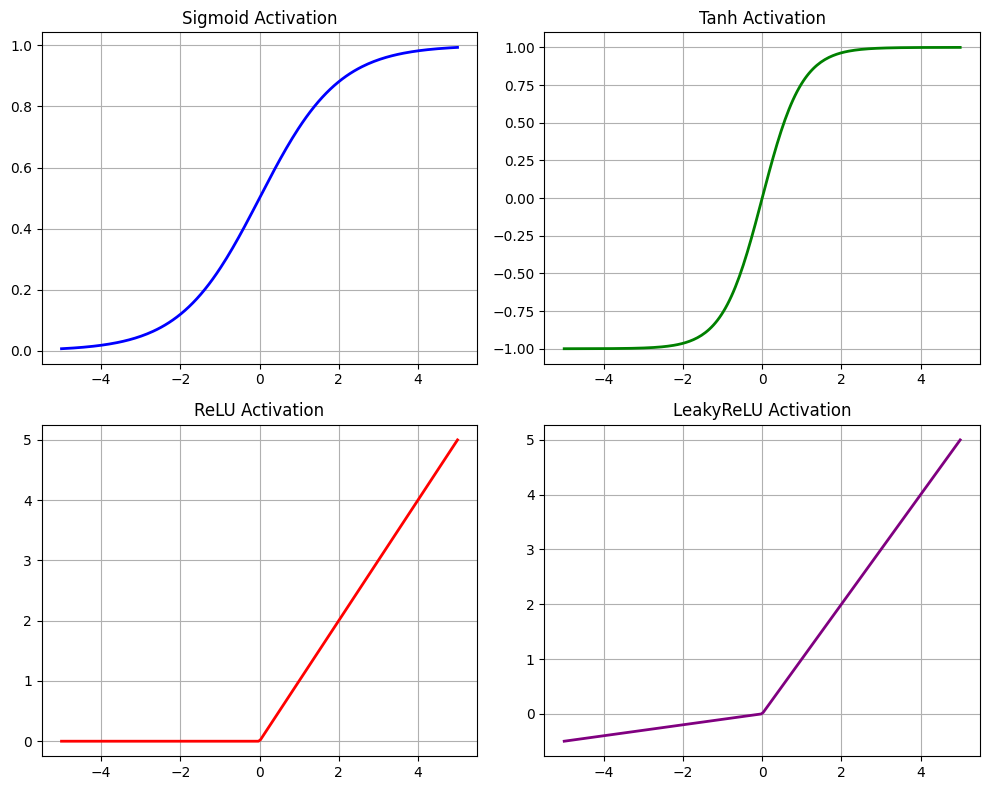

In [4]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def tanh(z):
    return np.tanh(z)

def relu(z):
    return np.maximum(0, z)

def leaky_relu(z, alpha=0.1):
    return np.where(z > 0, z, alpha * z)

z = np.linspace(-5, 5, 200)

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes[0,0].plot(z, sigmoid(z), color='blue', lw=2)
axes[0,0].set_title('Sigmoid Activation')
axes[0,0].grid(True)

axes[0,1].plot(z, tanh(z), color='green', lw=2)
axes[0,1].set_title('Tanh Activation')
axes[0,1].grid(True)

axes[1,0].plot(z, relu(z), color='red', lw=2)
axes[1,0].set_title('ReLU Activation')
axes[1,0].grid(True)

axes[1,1].plot(z, leaky_relu(z), color='purple', lw=2)
axes[1,1].set_title('LeakyReLU Activation')
axes[1,1].grid(True)

plt.tight_layout()
plt.show()

## Mini-Exercise
**Question:** Why does the derivative of ReLU equal 0 for $z < 0$, and what problem does this create during neural network training?

---

# Solving the XOR Problem with Multiple Perceptrons

<img src="page23.png" style="float: right; width: 650px; margin-left: 20px; margin-bottom: 10px; border: 1px solid #ccc; border-radius: 5px;">

In the previous examples, a single perceptron was sufficient to implement the **AND** and **OR** logic gates because both problems are **linearly separable**. A single decision boundary can correctly classify all possible input combinations.

However, the XOR gate behaves differently. The output belongs to two opposite corners of the input space, making it impossible to separate the classes using only one straight decision boundary.

Because of this limitation, a **single perceptron cannot solve the XOR problem**.

<div style="clear: both;"></div>
<br>

<img src="page33.png" style="float: right; width: 650px; margin-left: 20px; margin-bottom: 10px; border: 1px solid #ccc; border-radius: 5px;">

The solution is to use a **Multilayer Perceptron (MLP)**. Instead of relying on one neuron, the network introduces a **hidden layer** containing multiple perceptrons. Each hidden neuron learns a different decision boundary, while the output neuron combines these intermediate results to produce the final XOR output.

<div style="clear: both;"></div>
<br>

<img src="page34.png" style="float: right; width: 650px; margin-left: 20px; margin-bottom: 10px; border: 1px solid #ccc; border-radius: 5px;">

One possible implementation is to let the hidden neurons detect simpler logical relationships such as **OR** and **NAND**. The output neuron then combines these hidden outputs using an **AND** operation.

<div style="clear: both;"></div>
<br>

<img src="page35.png" style="float: right; width: 350px; margin-left: 20px; margin-bottom: 10px; border: 1px solid #ccc; border-radius: 5px;">

This leads to the following decomposition:

$$
XOR = (OR) \land (NAND)
$$

This decomposition transforms the original non-linearly separable problem into several simpler linearly separable sub-problems. Each hidden neuron solves one simple task, and together they allow the network to correctly classify all XOR input combinations.

This example clearly demonstrates why hidden layers are important in neural networks. They enable the model to learn more complex decision boundaries that cannot be represented by a single perceptron.

<div style="clear: both;"></div>


---